# Predictive Maintenance: Machine Failure Classification

**Objective:** Build a multi-class classification model to predict the type of machine failure (e.g., Tool Wear Failure, Heat Dissipation Failure, etc.) using sensor readings such as temperature, rotational speed, torque, and tool wear.

**Dataset:** [Machine Predictive Maintenance Classification](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification) — 10,000 synthetic records based on real-world manufacturing sensor data.

**Approach:**
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Engineering
5. Train / Test Split
6. Imbalance Handling (SMOTENC)
7. Baseline Models (LR, KNN, DT, RF, XGBoost) — default params
8. Top-2 Model Selection
9. Hyperparameter Tuning (RandomizedSearchCV)
10. Final Model Evaluation — Binary Target
11. Final Model Evaluation — Failure Type (multi-class)
12. Feature–Failure Relationship Analysis
13. Conclusions

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, f1_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, auc, make_scorer)
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")


Libraries loaded.


In [215]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv


In [216]:
data = pd.read_csv('/kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv')
print(f'Shape: {data.shape}')
data.head()

Shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


##  Exploratory Data Analysis (EDA)

In [217]:
# Basic info and missing values
print('=== Dataset Info ===')
data.info()
print('\n=== Missing Values ===')
print(data.isnull().sum())
print('\n=== Duplicates ===')
print(f'Duplicate rows: {data.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB

=== Missing Values ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature

In [218]:
print('=== Statistical Summary ===')
data.describe()


=== Statistical Summary ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


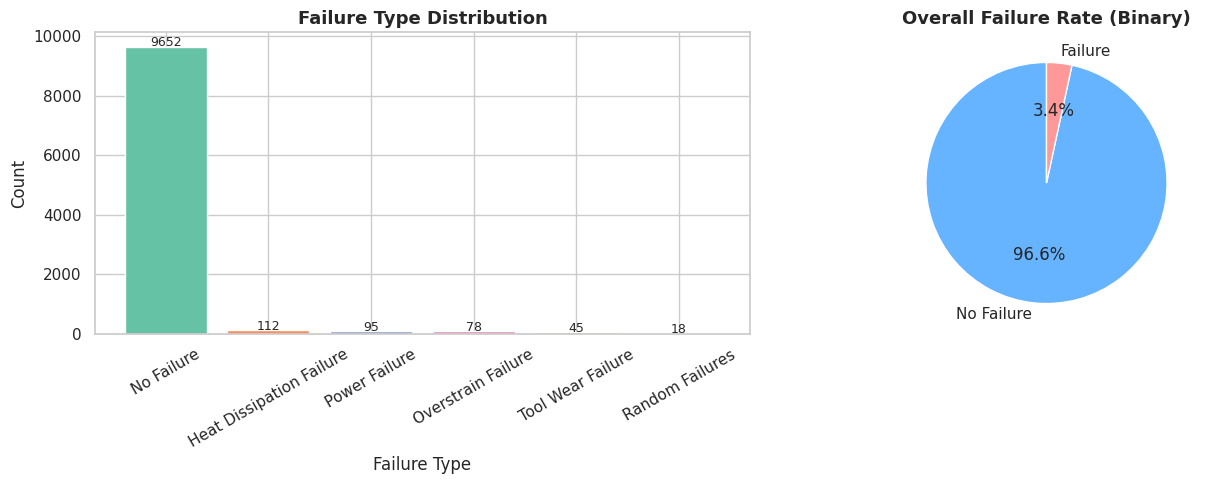

In [219]:
# Target Distribution: Failure Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Failure Type counts
failure_counts = data['Failure Type'].value_counts()
axes[0].bar(failure_counts.index, failure_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Failure Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Failure Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# Binary Target (Failure vs No Failure)
target_counts = data['Target'].value_counts()
axes[1].pie(target_counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[1].set_title('Overall Failure Rate (Binary)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [220]:
print('\nObservation: Dataset is heavily imbalanced — ~97% No Failure. This makes Precision-Recall curves more meaningful than accuracy.')



Observation: Dataset is heavily imbalanced — ~97% No Failure. This makes Precision-Recall curves more meaningful than accuracy.


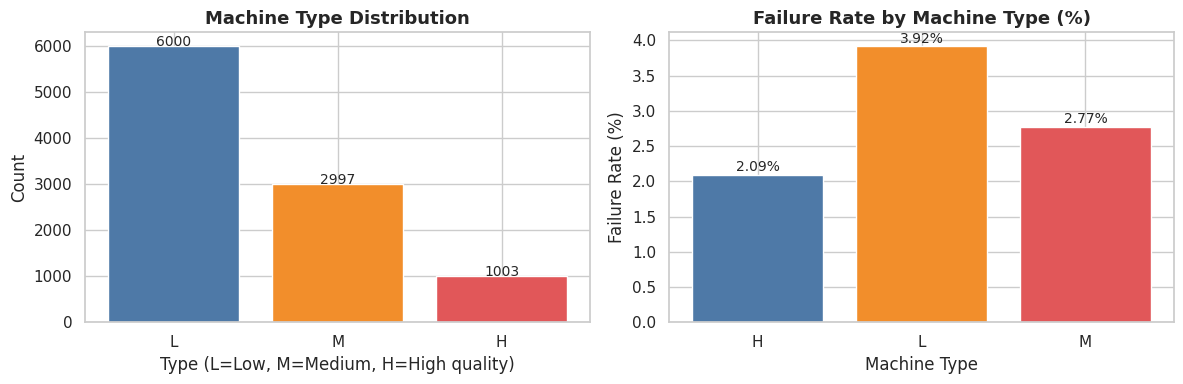


Observation: Low-quality machines (L) have a higher failure rate compared to Medium (M) and High (H).


In [223]:
# Machine Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = data['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['#4e79a7', '#f28e2b', '#e15759'])
axes[0].set_title('Machine Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type (L=Low, M=Medium, H=High quality)')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

# Failure rate per machine type
failure_by_type = data.groupby('Type')['Target'].mean().reset_index()
axes[1].bar(failure_by_type['Type'], failure_by_type['Target'] * 100,
            color=['#4e79a7', '#f28e2b', '#e15759'])
axes[1].set_title('Failure Rate by Machine Type (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Machine Type')
axes[1].set_ylabel('Failure Rate (%)')
for i, row in failure_by_type.iterrows():
    axes[1].text(i, row['Target'] * 100 + 0.05, f"{row['Target']*100:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print('\nObservation: Low-quality machines (L) have a higher failure rate compared to Medium (M) and High (H).')

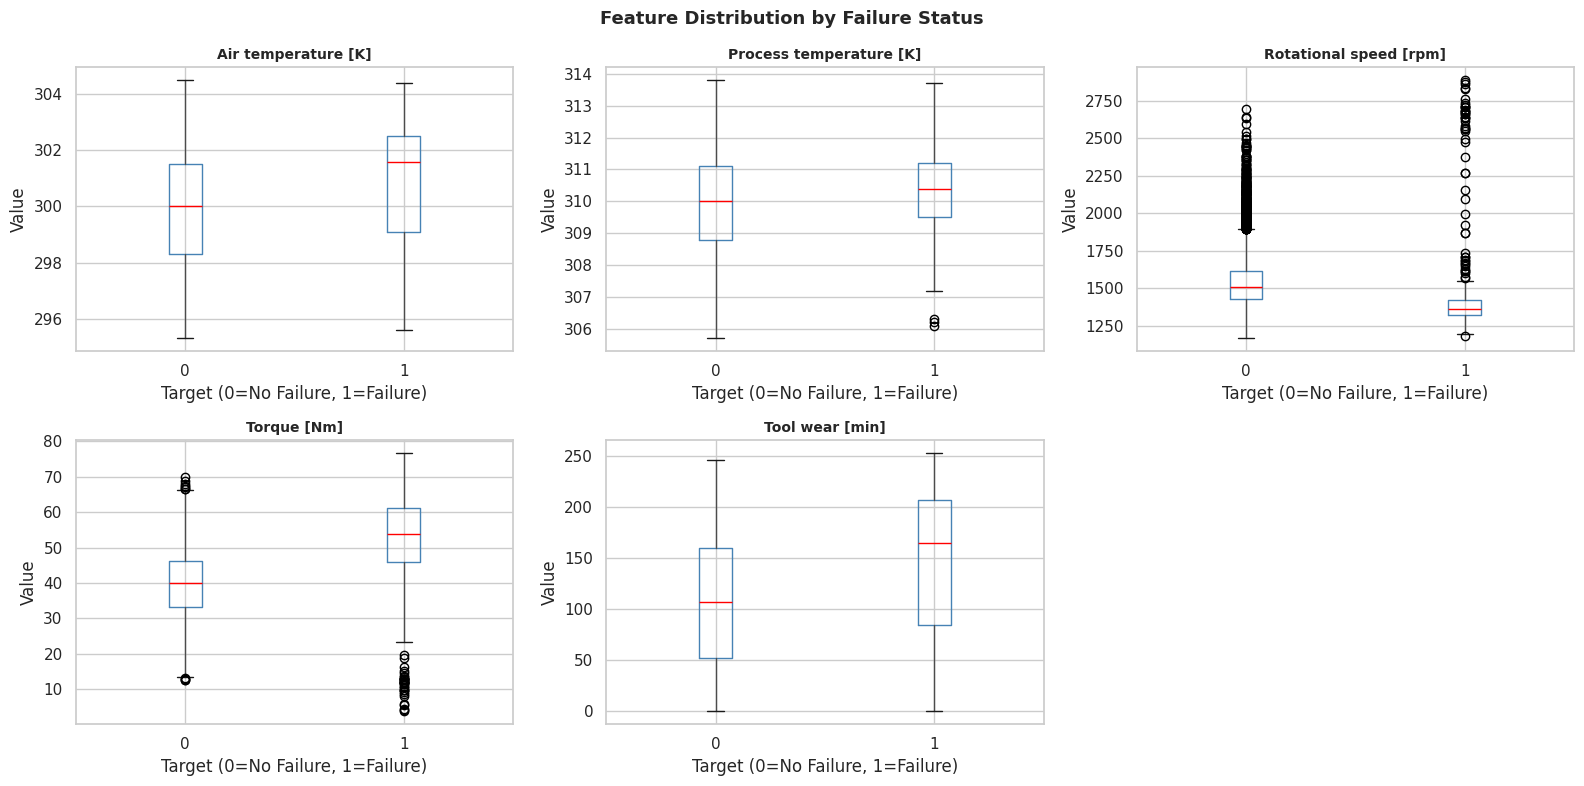


Observation: Air Temperature,Torque and Tool Wear show clear separation between failure and non-failure cases.


In [224]:
# Boxplots: Feature vs Failure
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data.boxplot(column=col, by='Target', ax=axes[i],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red'))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Target (0=No Failure, 1=Failure)')
    axes[i].set_ylabel('Value')

axes[5].axis('off')
plt.suptitle('Feature Distribution by Failure Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nObservation: Air Temperature,Torque and Tool Wear show clear separation between failure and non-failure cases.')

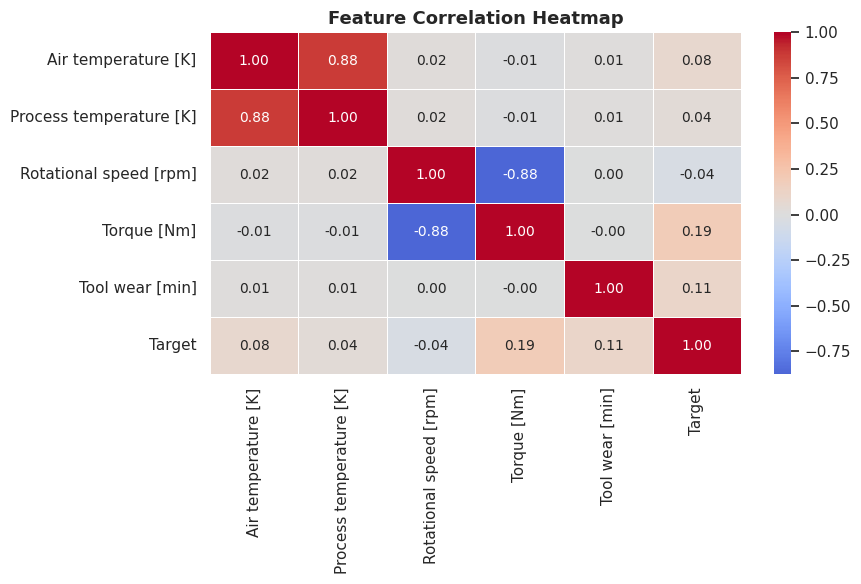


Observation: Air and Process temperatures are highly correlated (~0.88). Torque has the strongest correlation with Target.


In [225]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))
corr = data[numeric_cols + ['Target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nObservation: Air and Process temperatures are highly correlated (~0.88). Torque has the strongest correlation with Target.')

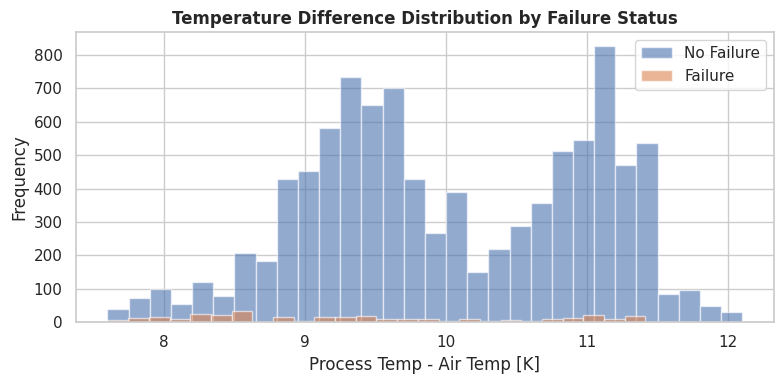


Observation: Machines that fail tend to have a narrower temperature differential, suggesting thermal stress concentration.


In [226]:
# Temperature Difference: a derived physical insight
data['Temp_diff'] = data['Process temperature [K]'] - data['Air temperature [K]']

plt.figure(figsize=(8, 4))
for label, grp in data.groupby('Target'):
    grp['Temp_diff'].hist(bins=30, alpha=0.6,
                          label='No Failure' if label == 0 else 'Failure')
plt.xlabel('Process Temp - Air Temp [K]')
plt.ylabel('Frequency')
plt.title('Temperature Difference Distribution by Failure Status', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('\nObservation: Machines that fail tend to have a narrower temperature differential, suggesting thermal stress concentration.')

In [227]:
# Drop irrelevant columns
data.drop(columns=['UDI', 'Product ID'], inplace=True, errors='ignore')

# Encode categorical features
le_type = LabelEncoder()
le_failure = LabelEncoder()

data['Type'] = le_type.fit_transform(data['Type'])
data['Failure Type'] = le_failure.fit_transform(data['Failure Type'])

print('Failure Type Classes:', list(le_failure.classes_))
print('Type Classes:', list(le_type.classes_))
data.head()

Failure Type Classes: ['Heat Dissipation Failure', 'No Failure', 'Overstrain Failure', 'Power Failure', 'Random Failures', 'Tool Wear Failure']
Type Classes: ['H', 'L', 'M']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_diff
0,2,298.1,308.6,1551,42.8,0,0,1,10.5
1,1,298.2,308.7,1408,46.3,3,0,1,10.5
2,1,298.1,308.5,1498,49.4,5,0,1,10.4
3,1,298.2,308.6,1433,39.5,7,0,1,10.4
4,1,298.2,308.7,1408,40.0,9,0,1,10.5


In [228]:
data.columns = (
    data.columns
      .str.replace('[', '', regex=False)
      .str.replace(']', '', regex=False)
)

In [229]:
data.columns

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Target',
       'Failure Type', 'Temp_diff'],
      dtype='object')

In [230]:
feature_cols = ['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temp_diff']

X = data[feature_cols].copy()
X.columns = ['Type', 'Air_temp_K', 'Process_temp_K',
             'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temp_diff']
feature_cols_clean = X.columns.tolist()
cat_idx = feature_cols_clean.index('Type')

y_binary = data['Target']
y_multi  = data['Failure Type']

# Split — stratify on multi-class target (more granular = safer stratification)
X_train, X_test, y_train_b, y_test_b, y_train_m, y_test_m = train_test_split(
    X, y_binary, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

print(f'Train : {X_train.shape[0]:>5} rows')
print(f'Test  : {X_test.shape[0]:>5} rows')
print(f'\nClass distribution (multi) in train:')
print(pd.Series(y_train_m).map(dict(enumerate(le_failure.classes_))).value_counts())

# Scaler — fit on train only (used for LR and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Train :  8000 rows
Test  :  2000 rows

Class distribution (multi) in train:
Failure Type
No Failure                  7722
Heat Dissipation Failure      90
Power Failure                 76
Overstrain Failure            62
Tool Wear Failure             36
Random Failures               14
Name: count, dtype: int64


## 6. Imbalance Handling — SMOTENC

**Why SMOTENC over plain SMOTE?**
`Type` is a categorical feature. SMOTE interpolates numerically — incorrect for categories.
SMOTENC uses the mode of nearest neighbours for categorical columns instead.

Applied **only to the training set**, after the split — no leakage into test.
We create two resampled sets: one for binary, one for multi-class.

> **Note on Random Failures:** Random failures have no reproducible sensor signature
> by definition. F1 ≈ 0 on that class is the expected answer, not a model deficiency.


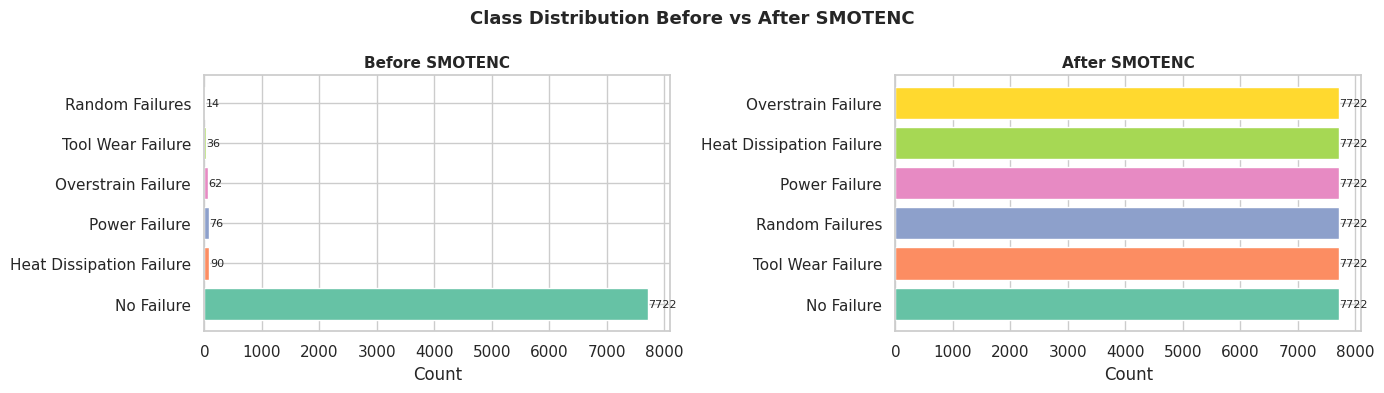

In [231]:
sm = SMOTENC(categorical_features=[cat_idx], random_state=42, k_neighbors=3)

# Multi-class resampled set (used for baseline + tuning)
X_train_res, y_train_res_m = sm.fit_resample(X_train, y_train_m)

# Binary resampled set
_, y_train_res_b = sm.fit_resample(X_train, y_train_b)

# Scaled versions for LR and KNN
X_train_res_scaled = scaler.transform(X_train_res)

label_map = dict(enumerate(le_failure.classes_))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

before = pd.Series(y_train_m).map(label_map).value_counts()
after  = pd.Series(y_train_res_m).map(label_map).value_counts()

axes[0].barh(before.index, before.values, color=sns.color_palette('Set2', len(before)))
axes[0].set_title('Before SMOTENC', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

axes[1].barh(after.index, after.values, color=sns.color_palette('Set2', len(after)))
axes[1].set_title('After SMOTENC', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=8)

plt.suptitle('Class Distribution Before vs After SMOTENC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Baseline Models — Default Parameters

Five classifiers trained on the SMOTENC-resampled training set, evaluated on the
**validation split** (inner 5-fold CV) using **Macro F1**.

Models:
- Logistic Regression — linear baseline
- KNN — distance-based, no assumptions on data shape
- Decision Tree — simple interpretable tree
- Random Forest — ensemble of trees, reduces variance
- XGBoost — gradient boosted trees, typically best on tabular data

Scaling applied for LR and KNN (required); tree-based models use raw features.


In [232]:
macro_f1 = make_scorer(f1_score, average='macro', zero_division=0)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'KNN'                : KNeighborsClassifier(n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(eval_metric='mlogloss', random_state=42,
                                          n_jobs=-1, verbosity=0),
}

needs_scale = {'Logistic Regression', 'KNN'}

from sklearn.model_selection import cross_val_score

baseline_scores = {}
print(f'{"Model":<22} {"Mean Macro F1":>14} {"Std":>8}')
print('─' * 47)

for name, model in baselines.items():
    X_tr = X_train_res_scaled if name in needs_scale else X_train_res
    scores = cross_val_score(model, X_tr, y_train_res_m,
                             cv=skf, scoring=macro_f1, n_jobs=-1)
    baseline_scores[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:<22} {scores.mean():>14.4f} {scores.std():>8.4f}')

print('─' * 47)


Model                   Mean Macro F1      Std
───────────────────────────────────────────────
Logistic Regression            0.8876   0.0036
KNN                            0.9806   0.0006
Decision Tree                  0.9921   0.0011
Random Forest                  0.9958   0.0006
XGBoost                        0.9959   0.0008
───────────────────────────────────────────────


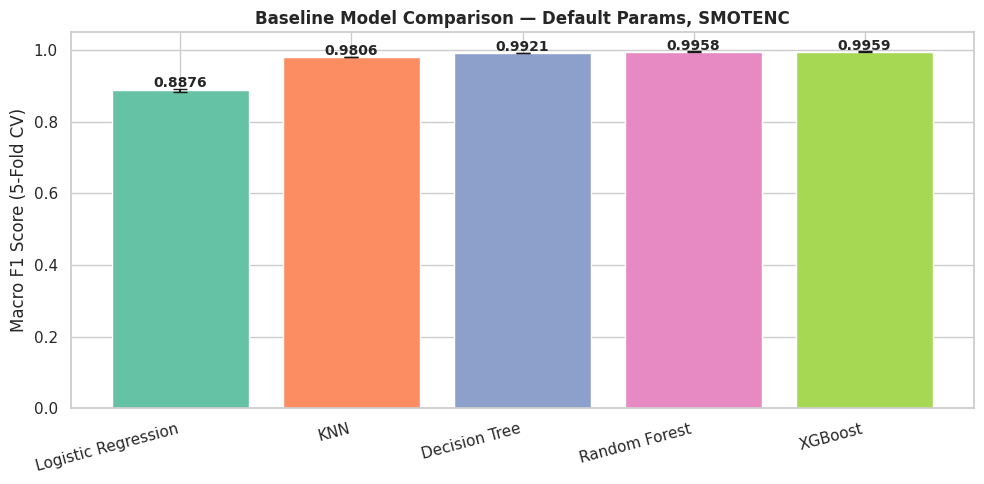

In [233]:
# Bar chart — baseline comparison
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(baseline_scores.keys())
means  = [baseline_scores[n]['mean'] for n in names]
stds   = [baseline_scores[n]['std']  for n in names]
colors = sns.color_palette('Set2', len(names))

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor='white')
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1 Score (5-Fold CV)')
ax.set_title('Baseline Model Comparison — Default Params, SMOTENC', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 8. Top-2 Model Selection

The two models with the highest mean Macro F1 on the 5-fold CV baseline are
selected for hyperparameter tuning.


In [234]:
sorted_models = sorted(baseline_scores.items(), key=lambda x: x[1]['mean'], reverse=True)
top2_names = [name for name, _ in sorted_models[:2]]

print('Top-2 models selected for tuning:')
for i, (name, scores) in enumerate(sorted_models[:2], 1):
    print(f'  {i}. {name:<22}  Mean Macro F1 = {scores["mean"]:.4f}  (std={scores["std"]:.4f})')


Top-2 models selected for tuning:
  1. XGBoost                 Mean Macro F1 = 0.9959  (std=0.0008)
  2. Random Forest           Mean Macro F1 = 0.9958  (std=0.0006)


## 9. Hyperparameter Tuning — Top-2 Models (RandomizedSearchCV)

`RandomizedSearchCV` with 3-fold stratified CV, targeting **Macro F1**.
20 random combinations sampled per model.
XGBoost also receives `sample_weight='balanced'` to further strengthen minority-class learning.


In [236]:
param_grids = {
    
    'Random Forest': {
        'n_estimators'    : randint(100, 200),
        'max_depth'       : randint(3, 5),
        'min_samples_leaf': randint(1, 10),
        'max_features'    : ['sqrt', 'log2'],
    },
    'XGBoost': {
        'n_estimators'    : randint(100, 200),
        'max_depth'       : randint(3, 5),
        'learning_rate'   : loguniform(0.01, 0.3),
        'subsample'       : uniform(0.6, 0.4),
        'min_child_weight': randint(1, 8),

    },
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
sw  = compute_sample_weight('balanced', y_train_res_m)

tuned_models  = {}
tuned_results = {}

for name in top2_names:
    print(f'\nTuning {name}...')
    base_model = baselines[name]
    use_sc = name in needs_scale
    X_tr   = X_train_res_scaled if use_sc else X_train_res

    fit_params = {}
    if name == 'XGBoost':
        fit_params = {'sample_weight': sw}

    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_grids[name],
        n_iter              = 20,
        scoring             = macro_f1,
        cv                  = cv3,
        random_state        = 42,
        n_jobs              = -1,
        verbose             = 0,
        refit               = True,
    )
    search.fit(X_tr, y_train_res_m, **fit_params)

    tuned_models[name]  = search.best_estimator_
    tuned_results[name] = search.best_score_

    print(f'  Best CV Macro F1 : {search.best_score_:.4f}')
    print(f'  Best params      : {search.best_params_}')



Tuning XGBoost...
  Best CV Macro F1 : 0.9941
  Best params      : {'learning_rate': np.float64(0.26656254771744614), 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 140, 'subsample': np.float64(0.718509402281633)}

Tuning Random Forest...
  Best CV Macro F1 : 0.8809
  Best params      : {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 183}


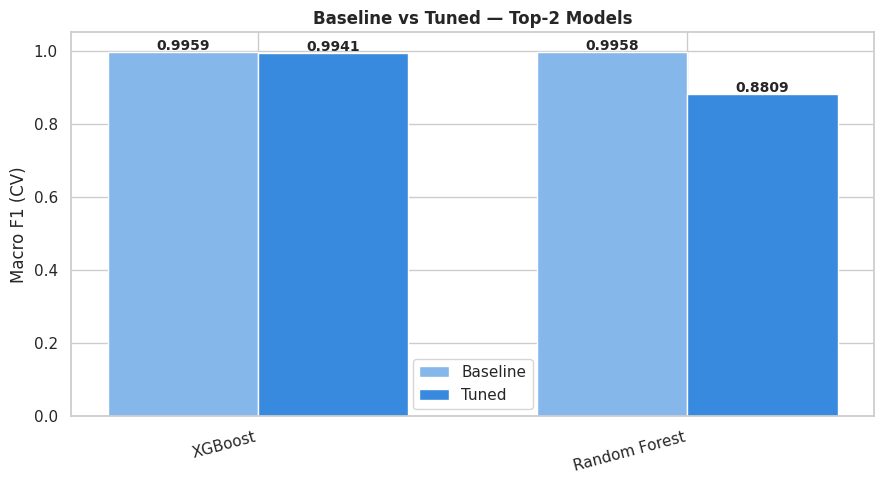

In [237]:
# Baseline vs Tuned comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(top2_names))
w = 0.35

bars1 = ax.bar(x - w/2, [baseline_scores[n]['mean'] for n in top2_names],
               w, label='Baseline', color='#85B7EB', edgecolor='white')
bars2 = ax.bar(x + w/2, [tuned_results[n] for n in top2_names],
               w, label='Tuned',    color='#378ADD', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top2_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1 (CV)')
ax.set_title('Baseline vs Tuned — Top-2 Models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [238]:
# Select best of the two tuned models
best_model_name = max(tuned_results, key=tuned_results.get)
best_model      = tuned_models[best_model_name]
use_scale_best  = best_model_name in needs_scale

print(f'Best model selected: {best_model_name}')
print(f'CV Macro F1        : {tuned_results[best_model_name]:.4f}')


Best model selected: XGBoost
CV Macro F1        : 0.9941


## 10. Final Evaluation — Binary Target (Failure vs No Failure)

The best tuned model is evaluated on the held-out test set for the **binary task**
(0 = No Failure, 1 = Any Failure). This answers: *"Does a machine fail or not?"*


In [257]:
X_eval_test = X_test_scaled if use_scale_best else X_test

# Multi-class predictions on original (unaugmented) test set
y_pred_m_test = best_model.predict(X_eval_test)

# Derive binary: No Failure → 0, any failure type → 1
no_fail_idx  = list(le_failure.classes_).index('No Failure')
y_pred_b     = (y_pred_m_test != no_fail_idx).astype(int)

# y_test_b is already 0/1 from the original split
print(f'=== {best_model_name} — Binary (derived from multi-class, real test set) ===\n')
print(classification_report(y_test_b, y_pred_b,
                             zero_division=0))

# print(classification_report(y_test_b, y_pred_b,
#                              target_names=['No Failure', 'Failure'],
#                              zero_division=0))


=== XGBoost — Binary (derived from multi-class, real test set) ===

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1934
           1       0.58      0.80      0.67        66

    accuracy                           0.97      2000
   macro avg       0.78      0.89      0.83      2000
weighted avg       0.98      0.97      0.98      2000



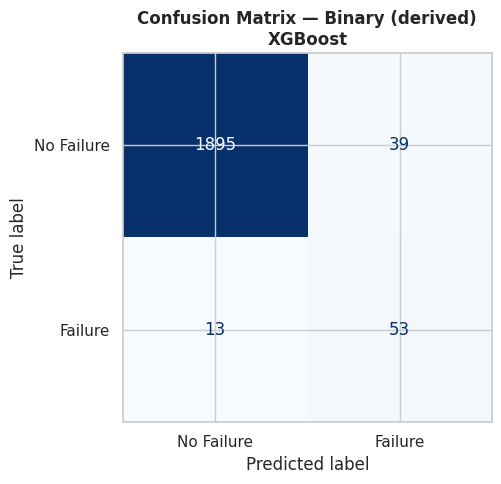

True Positives  (correctly caught failures)  : 53
False Negatives (missed failures — costly!)  : 13
False Positives (false alarms)               : 39
True Negatives  (correctly cleared)          : 1895


In [255]:
# Confusion matrix — binary
fig, ax = plt.subplots(figsize=(6, 5))
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b,
                               display_labels=['No Failure', 'Failure'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Binary (derived)\n{best_model_name}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_b.ravel()
print(f'True Positives  (correctly caught failures)  : {tp}')
print(f'False Negatives (missed failures — costly!)  : {fn}')
print(f'False Positives (false alarms)               : {fp}')
print(f'True Negatives  (correctly cleared)          : {tn}')


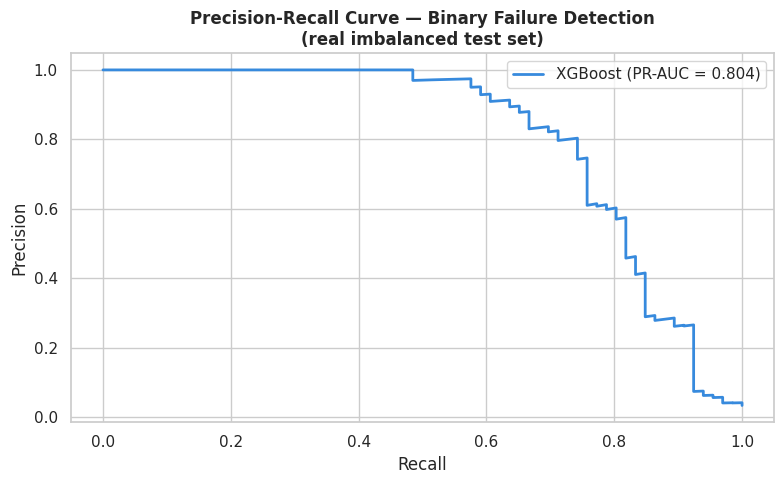


Note: PR-AUC preferred over ROC-AUC for imbalanced datasets.
A drop vs CV scores is expected and normal — SMOTENC inflates CV on synthetic points.


In [256]:
# PR Curve — binary (use probability of NOT being No Failure)
y_probs_m    = best_model.predict_proba(X_eval_test)
prob_failure = 1 - y_probs_m[:, no_fail_idx]   # P(any failure)

prec, rec, _ = precision_recall_curve(y_test_b, prob_failure)
pr_auc = auc(rec, prec)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, linewidth=2, color='#378ADD',
         label=f'{best_model_name} (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Binary Failure Detection\n(real imbalanced test set)',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('\nNote: PR-AUC preferred over ROC-AUC for imbalanced datasets.')
print('A drop vs CV scores is expected and normal — SMOTENC inflates CV on synthetic points.')


## 11. Final Evaluation — Failure Type (Multi-class)

The same model evaluated on the 6-class failure type target.
This answers: *"What kind of failure is occurring?"*


In [243]:
# Re-train best model on multi-class resampled target (already done above)
# Predict failure types on test set
y_pred_m = best_model.predict(X_eval_test)

print(f'=== {best_model_name} — Failure Type (Test Set) ===\n')
print(classification_report(y_test_m, y_pred_m,
                             target_names=le_failure.classes_,
                             zero_division=0))


=== XGBoost — Failure Type (Test Set) ===

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.92      1.00      0.96        22
              No Failure       0.99      0.98      0.99      1930
      Overstrain Failure       0.89      1.00      0.94        16
           Power Failure       0.79      0.79      0.79        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.97      2000
               macro avg       0.60      0.63      0.61      2000
            weighted avg       0.98      0.97      0.98      2000



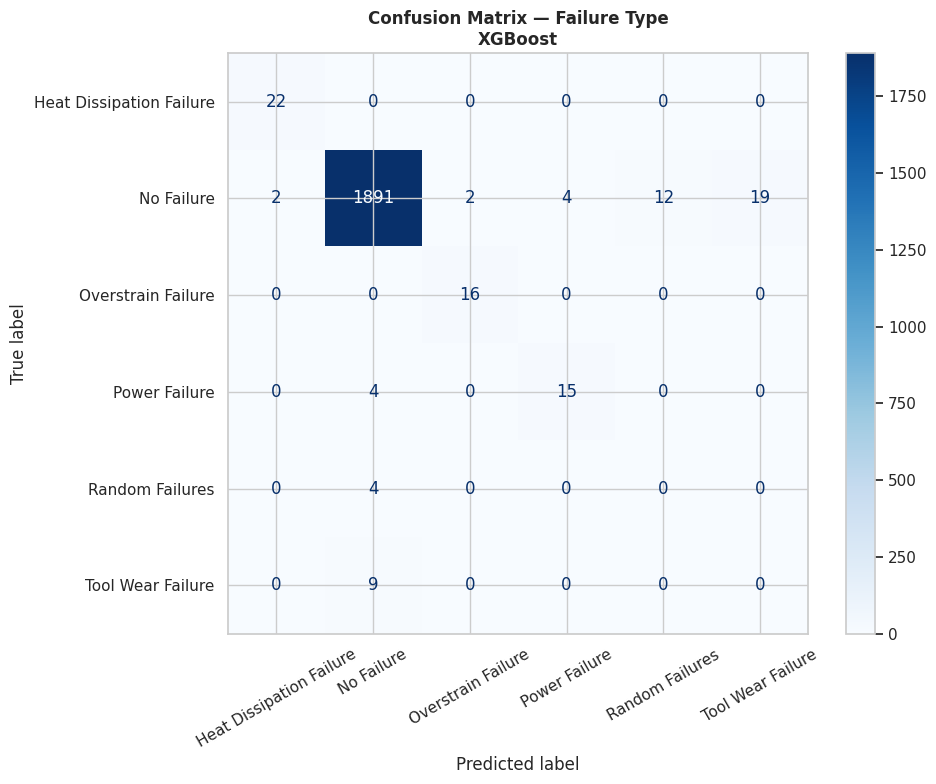

In [244]:
# Confusion matrix — multi-class failure types
fig, ax = plt.subplots(figsize=(10, 8))
cm_m = confusion_matrix(y_test_m, y_pred_m)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_m,
                               display_labels=le_failure.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Confusion Matrix — Failure Type\n{best_model_name}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


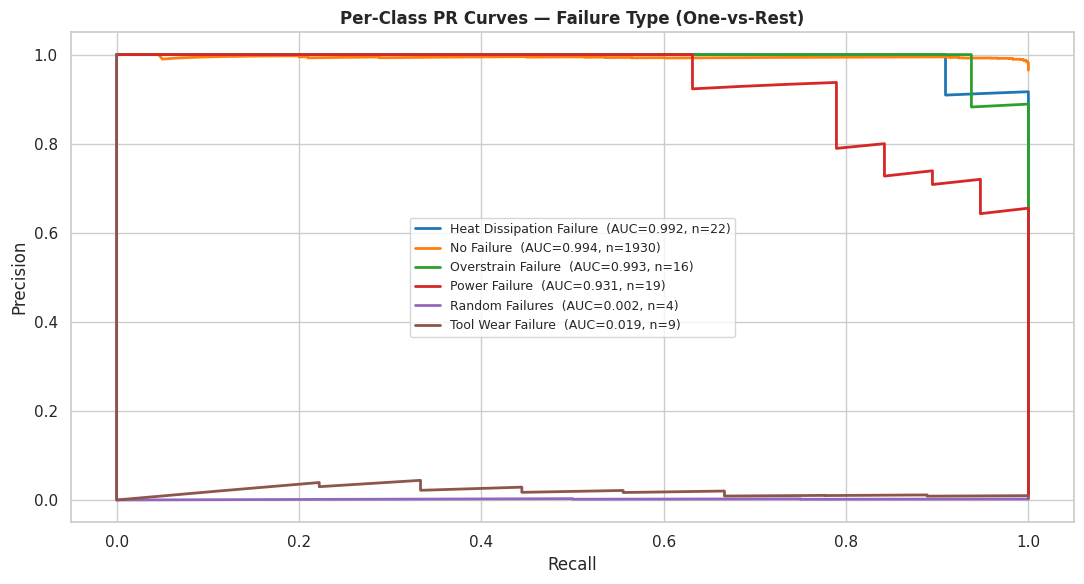

In [245]:
# Per-class PR-AUC (one-vs-rest)
y_probs_m = best_model.predict_proba(X_eval_test)
colors_list = sns.color_palette('tab10', len(le_failure.classes_))

plt.figure(figsize=(11, 6))
for i, cls_name in enumerate(le_failure.classes_):
    y_bin = (y_test_m == i).astype(int)
    if y_bin.sum() == 0:
        continue
    prec_c, rec_c, _ = precision_recall_curve(y_bin, y_probs_m[:, i])
    auc_val = auc(rec_c, prec_c)
    plt.plot(rec_c, prec_c,
             label=f'{cls_name}  (AUC={auc_val:.3f}, n={y_bin.sum()})',
             linewidth=2, color=colors_list[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Per-Class PR Curves — Failure Type (One-vs-Rest)', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 12. Feature–Failure Relationship Analysis

Understanding *which sensor readings drive each failure type* —
critical for translating model predictions into actionable maintenance rules.


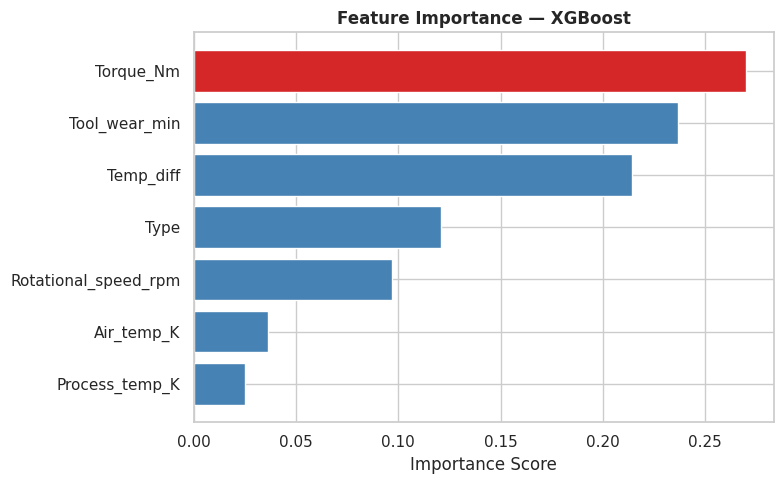


Observation: Tool Wear and Torque are consistently top predictors.
Temp_diff (engineered) adds signal beyond raw temperatures.


In [253]:
# Feature importance (tree-based best model only)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_,
                            index=feature_cols_clean).sort_values(ascending=True)
    colors_bar = ['#d62728' if v == importances.max() else 'steelblue'
                  for v in importances.values]

    plt.figure(figsize=(8, 5))
    plt.barh(importances.index, importances.values, color=colors_bar)
    plt.title(f'Feature Importance — {best_model_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    print('\nObservation: Tool Wear and Torque are consistently top predictors.')
    print('Temp_diff (engineered) adds signal beyond raw temperatures.')
else:
    # For LR — show absolute coefficients averaged across classes
    coef = np.abs(best_model.coef_).mean(axis=0)
    coef_s = pd.Series(coef, index=feature_cols_clean).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    plt.barh(coef_s.index, coef_s.values, color='steelblue')
    plt.title(f'Feature Coefficients (abs mean) — {best_model_name}',
              fontsize=12, fontweight='bold')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()


Key Findings

Sensor signatures are failure-specific. Each detectable failure type maps to a distinct sensor pattern — narrow temperature differentials drive Heat Dissipation Failures, high torque drives Overstrain Failures, and combined torque-speed patterns indicate Power Failures. These relationships were confirmed both visually (feature–failure heatmap, scatter plots) and through model feature importances.


Torque and Tool Wear are the strongest predictors across all models and failure types, with the engineered Temp_diff feature adding meaningful signal beyond the raw temperature readings.


SMOTENC inflates cross-validation scores. CV Macro F1 of 0.99 dropped to 0.61 on the real test set — a direct consequence of evaluating on synthetic minority samples that are easier to classify than real ones. Reporting test set performance on the original imbalanced distribution is the correct practice.

Random Failures are inherently unpredictable from sensor data. F1 = 0.00 on this class is the statistically correct result, not a model failure. These events have no reproducible sensor signature and should be addressed through hardware redundancy rather than ML prediction.


Tool Wear Failure underperforms due to data scarcity (9 test samples), not a weak sensor signal. The Tool wear [min] feature directly measures wear — with more labelled examples this class would likely match the performance of Heat Dissipation and Overstrain.